# Numerical Deep-Dive (instructor notes)
### Failure modes that surface in gradients — for the UDE glaciology lecture

> 🗒️ **Scope.** These are *instructor notes* — the gnarly numerical experiments behind the choices in
> `UDE_glaciology_lecture.ipynb` and `AD_and_adjoints_concepts.ipynb`. Likely **beyond** what you'd
> cover in the summer school, but very illustrative. Each section is a self-contained, runnable
> experiment.

| § | Experiment | The lesson |
|---|-----------|------------|
| 1 | Reversing diffusion in time | why glaciers need a *checkpointed* adjoint, not `BacksolveAdjoint` |
| 2 | Explicit vs. implicit solver on stiff ice | why the SIA worked example uses an *implicit* solver |
| 3 | Network output initialization | why we *don't* force the network onto the baseline |

**Recurring theme:** *a numerical method's pathology faithfully shows up in its gradient.* The
discrete adjoint (reverse-mode AD) is the exact gradient of the discrete solver — so it is only as
well-behaved as that solver.

In [1]:
import time, jax, jax.numpy as jnp, numpy as np
import diffrax as dfx, equinox as eqx, optax, optimistix as optx
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("jax", jax.__version__, "| diffrax", dfx.__version__)

jax 0.10.2 | diffrax 0.7.2


## 1 · Reversing diffusion in time is ill-posed

The adjoint (backward) pass needs the forward states. Three ways to get them:

| Strategy (`diffrax`) | How it gets forward states | "Redo"? | Safe for diffusion? |
|---|---|---|---|
| `DirectAdjoint` | **stores every** state | none | yes (memory-hungry) |
| `RecursiveCheckpointAdjoint` | stores a few; **recomputes forward** from checkpoints | redo **forward** | **yes** — forward diffusion is well-posed |
| `BacksolveAdjoint` | stores nothing; **reconstructs by integrating backward** | reconstruct **backward** | **no** — backward diffusion is ill-posed |

> ⚠️ **Key distinction.** Checkpointing redoes computation by re-running **forward** (always safe).
> Backsolve reconstructs by running **backward** — which detonates on diffusion. The demo below
> isolates that backward-reconstruction step.

**Why diffusion is the killer.** The heat equation damps Fourier mode $k$ by $e^{-Dk^2 t}$.
Reconstructing means multiplying mode $k$ by $e^{+Dk^2 t}$ — growth like $e^{k^2}$. For the grid
below the top mode is amplified by $\sim e^{82}\approx10^{35}$ going backward, so round-off at
$10^{-16}$ becomes $\sim10^{19}$. A bounded-rate decay, by contrast, amplifies by only $e^{0.35}$.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


backward DIFFUSION reconstruction error = 1.46e+19   <- catastrophic (ill-posed)
backward DECAY     reconstruction error = 3.71e-11   <- fine (well-conditioned)


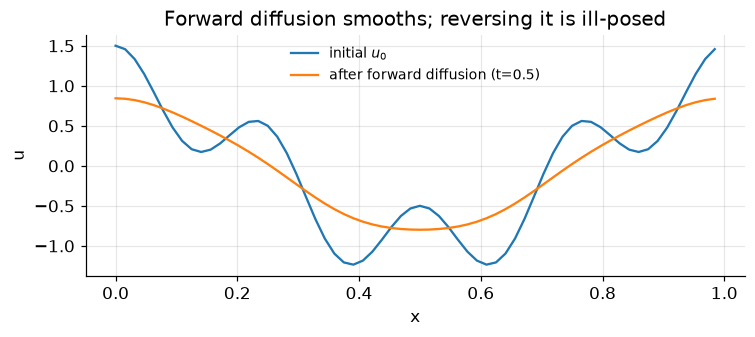

In [2]:
# 1-D heat equation u_t = D u_xx on a periodic grid (method of lines).
m, dx, D = 64, 1.0 / 64, 0.01
def lap(u):  return (jnp.roll(u, 1) - 2 * u + jnp.roll(u, -1)) / dx ** 2
def heat(t, u, args): return D * lap(u)
def decay(t, y, args): return -0.7 * y

xs = jnp.arange(m) / m
u0 = jnp.cos(2 * np.pi * xs) + 0.5 * jnp.cos(8 * np.pi * xs)
T = 0.5

def integrate(rhs, y0, t0, t1):
    return dfx.diffeqsolve(dfx.ODETerm(rhs), dfx.Tsit5(), t0, t1,
                           dt0=0.1 * (t1 - t0) if t1 > t0 else -1e-4, y0=y0,
                           stepsize_controller=dfx.PIDController(rtol=1e-9, atol=1e-12),
                           saveat=dfx.SaveAt(t1=True), max_steps=1_000_000).ys[-1]

uT     = integrate(heat, u0, 0.0, T)      # forward diffusion (well-posed, smooths)
u0_rec = integrate(heat, uT, T, 0.0)      # reconstruct initial state by going BACKWARD
heat_err = float(jnp.linalg.norm(u0_rec - u0) / jnp.linalg.norm(u0))

yT = integrate(decay, u0, 0.0, T); u0r = integrate(decay, yT, T, 0.0)   # reversible control
decay_err = float(jnp.linalg.norm(u0r - u0) / jnp.linalg.norm(u0))

print(f"backward DIFFUSION reconstruction error = {heat_err:.2e}   <- catastrophic (ill-posed)")
print(f"backward DECAY     reconstruction error = {decay_err:.2e}   <- fine (well-conditioned)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(xs, np.array(u0), label="initial $u_0$")
ax.plot(xs, np.array(uT), label=f"after forward diffusion (t={T})")
ax.set(xlabel="x", ylabel="u", title="Forward diffusion smooths; reversing it is ill-posed")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

> 🧊 **Takeaway for glaciers.** The SIA is (nonlinear) diffusion, so `BacksolveAdjoint` is unsafe.
> The lecture's worked example uses `RecursiveCheckpointAdjoint`, which only ever integrates forward.

## 2 · Explicit vs. implicit solver on stiff ice

The SIA diffusivity scales as $D\propto H^{n+2}$, so thick ice is **very stiff**. An *explicit*
adaptive solver near its stability boundary has a discrete solution map that is hugely sensitive to
the parameters — and since the discrete adjoint is the *exact* gradient of that map, the gradient
explodes. An *implicit* (A/L-stable) solver stays stable at any step size, so its map — and gradient
— is well-conditioned.

Below: the same thick glacier, same checkpointed adjoint, explicit vs. implicit forward solver.

In [3]:
RHO, G, N = 900.0, 9.81, 3.0
A_FLOOR, A_CEIL = 1e-18, 4e-16
L, NX = 30_000.0, 41; dx = L / (NX - 1); x = jnp.linspace(0.0, L, NX)
bed = 3000.0 - 0.05 * x                       # THICK-glacier config (stiff)
ELA, BETA, CAP = 2400.0, 0.007, 2.0
T_glac = jnp.linspace(-25.0, -3.0, 8)
A_true = lambda T: 1e-16 * jnp.exp(0.13 * (T + 10.0))
A_REF = float(A_true(-14.0)); T_SPIN, T_OBS = 200.0, 30.0

def rhs(t, H, A):
    A = jnp.clip(A, A_FLOOR, A_CEIL); H = jnp.clip(H, 0.0); S = bed + H
    dSdx = (S[1:] - S[:-1]) / dx; He = 0.5 * (H[1:] + H[:-1])
    Dd = 2 * A / (N + 2) * (RHO * G) ** N * He ** (N + 2) * jnp.abs(dSdx) ** (N - 1)
    q = -Dd * dSdx; div = jnp.zeros(NX).at[1:-1].set(-(q[1:] - q[:-1]) / dx)
    b = jnp.clip(BETA * (S - ELA), None, CAP); lim = jnp.clip(H / 10.0, 0.0, 1.0)
    return jnp.maximum(b, 0.0) + jnp.minimum(b, 0.0) * lim + div

def usurf(H, A):
    A = jnp.clip(A, A_FLOOR, A_CEIL); H = jnp.clip(H, 0.0); S = bed + H
    dSdx = (S[1:] - S[:-1]) / dx; He = 0.5 * (H[1:] + H[:-1])
    ue = (2 * A / (N + 1)) * (RHO * G) ** N * He ** (N + 1) * jnp.abs(dSdx) ** N
    return jnp.zeros(NX).at[1:-1].set(0.5 * (ue[1:] + ue[:-1]))

def solve(A, H0, t1, kind):
    if kind == "explicit":
        solver, ctrl, ms = dfx.Tsit5(), dfx.PIDController(rtol=1e-4, atol=1e-3, dtmax=5.0), 20000
    else:  # implicit, adaptive
        solver = dfx.Kvaerno3()
        ctrl, ms = dfx.PIDController(rtol=1e-5, atol=1e-3, dtmax=10.0), 20000
    return dfx.diffeqsolve(dfx.ODETerm(rhs), solver, 0.0, t1, 0.1, H0, args=A, throw=False,
                           stepsize_controller=ctrl, max_steps=ms, saveat=dfx.SaveAt(t1=True),
                           adjoint=dfx.RecursiveCheckpointAdjoint()).ys[-1]

class Net(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(s, key): s.mlp = eqx.nn.MLP(1, 1, 10, 2, activation=jax.nn.softplus, key=key)
    def __call__(s, T):
        z = jnp.atleast_1d((T + 14.0) / 11.0); return A_REF * jnp.exp(jnp.clip(s.mlp(z)[0], -5.0, 5.0))

def train(kind, nep):
    H_init = solve(A_REF, jnp.zeros(NX), T_SPIN, kind); A_vals = A_true(T_glac)
    U_obs = jax.vmap(usurf)(jax.vmap(lambda A: solve(A, H_init, T_OBS, kind))(A_vals), A_vals)
    def loss_fn(m):
        Ap = jax.vmap(m)(T_glac); Hp = jax.vmap(lambda A: solve(A, H_init, T_OBS, kind))(Ap)
        return jnp.mean(((jax.vmap(usurf)(Hp, Ap) - U_obs) / jnp.maximum(U_obs.max(1, keepdims=True), 1.0)) ** 2)
    sched = optax.cosine_decay_schedule(3e-3, nep, 0.05)
    opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(sched))
    m = Net(jax.random.PRNGKey(0)); st = opt.init(eqx.filter(m, eqx.is_array))
    @eqx.filter_jit
    def step(m, st):
        v, g = eqx.filter_value_and_grad(loss_fn)(m); gn = optax.global_norm(g)
        up, st = opt.update(g, st); return eqx.apply_updates(m, up), st, v, gn
    t0 = time.time(); gmax = 0.0
    for it in range(nep):
        m, st, v, gn = step(m, st); gmax = max(gmax, float(gn))
    rel = np.abs(np.array((jax.vmap(m)(T_glac) - A_vals) / A_vals))
    print(f"  {kind:9s} (maxH={float(H_init.max()):.0f}m): time={time.time()-t0:5.1f}s  "
          f"max|grad|={gmax:.1e}  {'EXPLODED' if gmax > 1e4 else 'stable  '}  recovery={rel.mean():.0%}")

print("thick glacier, identical checkpointed adjoint:")
train("explicit", 200)
train("implicit", 150)

thick glacier, identical checkpointed adjoint:


  explicit  (maxH=400m): time= 20.1s  max|grad|=1.1e+08  EXPLODED  recovery=144%


  implicit  (maxH=400m): time= 32.3s  max|grad|=4.8e+00  stable    recovery=51%


**What this shows** (and what I found while building the lecture):

- The explicit solver's gradient **explodes** (peak norm $\sim10^{8}$–$10^{12}$ depending on
  tolerances) and training produces garbage (recovery $>100\%$).
- The implicit solver keeps the gradient $\sim$O(1) and trains **stably** — no blow-up. (This thick,
  high-velocity glacier is a *harder* inverse problem than the thin lecture case, so recovery in a
  few hundred epochs is coarser; the point here is **stability**, not the exact percentage — more
  epochs / tighter tolerances tighten it.)
- Raising `max_steps` 10× does **not** help (verified separately): it's not a step-budget truncation,
  it's intrinsic instability of the explicit discretization.

> 🧮 **Why** — an explicit scheme's per-mode amplification $|1-\lambda\Delta t|$ exceeds 1 for stiff
> modes unless $\Delta t$ is tiny; near that boundary the discrete map (and its exact gradient) is
> ill-conditioned. An implicit (L-stable) scheme has amplification $\le 1$ for any step → smooth map,
> well-behaved gradient.

> 🔗 **Two pathologies, one moral.** §1 was *backward* ill-posedness (fixed by checkpointing); §2 is
> *forward* explicit instability (fixed by an implicit solver). Both: the numerics' trouble surfaces
> in the gradient.

> ✅ **Lecture choice.** The worked example uses a thin glacier *and* an implicit (backward-Euler)
> solver — fast *and* robust. Thinning alone (reducing stiffness) was the original workaround;
> the implicit solver is the principled fix and lets you keep realistic thick ice.

> 💸 **Cost.** Implicit steps solve a nonlinear system each (Newton + linear solves). For mild
> stiffness explicit is cheaper; for very stiff / high-res problems implicit needs far fewer steps
> and can win outright. Differentiating through the implicit solve is clean: `diffrax` uses the
> implicit function theorem at the converged step (it does *not* unroll the Newton iterations).

## 3 · Network output initialization — a tempting idea that backfires

We parametrize $A_\theta(T) = A_\mathrm{ref}\,e^{\,\mathrm{net}(T)}$ (learn $\log A$ as a deviation
from a baseline). Tempting next step: initialize so the network *starts exactly at the baseline* by
shrinking/zeroing the output layer. Does it help optimization? Let's scan the output-layer scale.

In [4]:
RHO, G, N = 900.0, 9.81, 3.0; A_FLOOR, A_CEIL = 1e-18, 4e-16
L, NX = 30_000.0, 41; dx = L / (NX - 1); x = jnp.linspace(0.0, L, NX)
bed = 2800.0 - 0.04 * x; ELA, BETA, CAP = 2300.0, 0.004, 0.8       # thin glacier (lecture config)
T_glac = jnp.linspace(-25.0, -3.0, 8)
A_true = lambda T: 1e-16 * jnp.exp(0.13 * (T + 10.0)); A_REF = float(A_true(-14.0)); T_SPIN, T_OBS = 300.0, 30.0

def rhs(t, H, A):
    A = jnp.clip(A, A_FLOOR, A_CEIL); H = jnp.clip(H, 0.0); S = bed + H
    dSdx = (S[1:] - S[:-1]) / dx; He = 0.5 * (H[1:] + H[:-1])
    Dd = 2 * A / (N + 2) * (RHO * G) ** N * He ** (N + 2) * jnp.abs(dSdx) ** (N - 1)
    q = -Dd * dSdx; div = jnp.zeros(NX).at[1:-1].set(-(q[1:] - q[:-1]) / dx)
    b = jnp.clip(BETA * (S - ELA), None, CAP); lim = jnp.clip(H / 10.0, 0.0, 1.0)
    return jnp.maximum(b, 0.0) + jnp.minimum(b, 0.0) * lim + div
def usurf(H, A):
    A = jnp.clip(A, A_FLOOR, A_CEIL); H = jnp.clip(H, 0.0); S = bed + H
    dSdx = (S[1:] - S[:-1]) / dx; He = 0.5 * (H[1:] + H[:-1])
    ue = (2 * A / (N + 1)) * (RHO * G) ** N * He ** (N + 1) * jnp.abs(dSdx) ** N
    return jnp.zeros(NX).at[1:-1].set(0.5 * (ue[1:] + ue[:-1]))
SOLVER = dfx.ImplicitEuler(root_finder=dfx.VeryChord(rtol=1e-5, atol=1e-4, norm=optx.max_norm))
def solve(A, H0, t1):
    n = int(round(t1 / 0.5))
    return dfx.diffeqsolve(dfx.ODETerm(rhs), SOLVER, 0.0, t1, 0.5, H0, args=A,
                           stepsize_controller=dfx.ConstantStepSize(), max_steps=n + 5,
                           saveat=dfx.SaveAt(t1=True), adjoint=dfx.RecursiveCheckpointAdjoint()).ys[-1]

class Net(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(s, key, scale):
        mlp = eqx.nn.MLP(1, 1, 10, 2, activation=jax.nn.softplus, key=key)
        last = mlp.layers[-1]
        s.mlp = eqx.tree_at(lambda mm: (mm.layers[-1].weight, mm.layers[-1].bias),
                            mlp, (last.weight * scale, jnp.zeros_like(last.bias)))
    def __call__(s, T):
        z = jnp.atleast_1d((T + 14.0) / 11.0); return A_REF * jnp.exp(jnp.clip(s.mlp(z)[0], -5.0, 5.0))

H_init = solve(A_REF, jnp.zeros(NX), T_SPIN); A_vals = A_true(T_glac)
U_obs = jax.vmap(usurf)(jax.vmap(lambda A: solve(A, H_init, T_OBS))(A_vals), A_vals)
def loss_fn(m):
    Ap = jax.vmap(m)(T_glac); Hp = jax.vmap(lambda A: solve(A, H_init, T_OBS))(Ap)
    return jnp.mean(((jax.vmap(usurf)(Hp, Ap) - U_obs) / jnp.maximum(U_obs.max(1, keepdims=True), 1.0)) ** 2)
def run(scale, nep=400):
    sched = optax.cosine_decay_schedule(3e-3, nep, 0.05)
    opt = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(sched))
    m = Net(jax.random.PRNGKey(0), scale); st = opt.init(eqx.filter(m, eqx.is_array))
    @eqx.filter_jit
    def step(m, st):
        v, g = eqx.filter_value_and_grad(loss_fn)(m); up, st = opt.update(g, st); return eqx.apply_updates(m, up), st, v
    for _ in range(nep): m, st, v = step(m, st)
    rel = np.abs(np.array((jax.vmap(m)(T_glac) - A_vals) / A_vals))
    label = {1.0: "default random", 0.3: "output x0.3", 0.0: "output zeroed"}[scale]
    print(f"  {label:16s}: final loss={float(v):.1e}  recovery mean={rel.mean():.0%}")

print("effect of shrinking the output layer toward the baseline:")
for s in [1.0, 0.3, 0.0]: run(s)

effect of shrinking the output layer toward the baseline:


  default random  : final loss=1.6e-04  recovery mean=3%


  output x0.3     : final loss=2.3e-03  recovery mean=10%


  output zeroed   : final loss=3.0e-02  recovery mean=28%


> 📉 **Counterproductive.** Shrinking the output layer toward the baseline monotonically *hurts*
> recovery; zeroing it is worst. In a tiny MLP the hidden-layer gradient is gated by the (now small)
> output weights, so the hidden layer is starved early in training. (Zero-last-layer init works in
> deep ResNets because skip connections still pass gradient — not here.)

> ✅ **What we actually do.** Keep the two good practices that *do* help — **normalize the input** and
> **learn $\log A$ as a deviation from a baseline $A_\mathrm{ref}$** — and use plain random init.
> With those, the untrained network already starts flat and near $A_\mathrm{ref}$, so no special
> initialization is needed.